# Import

In [1]:
import os
import sys
import numpy as np
import pandas as pd

notebook_path = os.getcwd()
parent_path = os.path.abspath(os.path.join(notebook_path, '..'))

if parent_path not in sys.path:
    sys.path.append(parent_path)

from market_data import KalshiAnalyzer, KalshiClient, KalshiFeatureEngineer, KalshiResearch

# Test

In [2]:
rspl = KalshiResearch()

series_data = rspl.fetch_series()
series_tickers = list(series_data.ticker.unique())

In [3]:
markets_data = rspl.fetch_markets_from_series(series_tickers[:100])

Extracting Markets: 100%|██████████| 100/100 [00:43<00:00,  2.30it/s]


In [4]:
tickers = list(markets_data.ticker.unique())
all_data = rspl.fetch_data(tickers)

Fetching: 100%|██████████| 391/391 [03:00<00:00,  2.17it/s]


In [5]:
def my_custom_features(df):
    processed_df = pd.DataFrame()
    processed_df['volatility_id'] = (df['high'] - df['low']) / df['open']
    processed_df['return'] = df.groupby(level=1)['close'].pct_change()
    processed_df['price_loc'] = (df['close'] - df['low']) / (df['high'] - df['low'] + 1e-9)
    processed_df['body_ratio'] = np.abs(df['close'] - df['open']) / (df['high'] - df['low'] + 1e-9)
    processed_df['dollar_volume'] = df['volume'] * df['mean_dollars']
    processed_df['mean_dev'] = (df['close_dollars'] - df['mean_dollars']) / df['mean_dollars']
    return processed_df

X, y = rspl.prepare_ml_ready(my_custom_features)

Executing custom feature engineering...


In [7]:
X

volatility_id_L0  \
ts                        ticker                                                    
2023-06-03 04:00:00+00:00 HURCTOT-23DEC01-T3                             0.000000   
                          HURCTOT-23DEC01-T7                             0.000000   
2023-06-04 04:00:00+00:00 HURCTOT-23DEC01-T5                             0.000000   
2023-06-05 04:00:00+00:00 ARCTICICEMIN-23OCT01-T4.8                      0.000000   
                          HURCTOT-23DEC01-T5                             0.000000   
...                                                                           ...   
2026-02-23 05:00:00+00:00 KXNEWPOPE-70-PPIZ                              0.000000   
                          KXNFLDRAFT1ST-26-1-BAL                         0.000000   
                          KXNFLDRAFT1ST-26-1-LV                          0.010870   
                          KXNFLDRAFT1ST-26-1-NYJ                         0.333333   
                          KXSTARTINGQBWEEK1-W1-26SEP15-CLE-DWAT          0.000000   

                                                                 return_L0  \
ts                        ticker                                             
2023-06-03 04:00:00+00:00 HURCTOT-23DEC01-T3                           NaN   
                          HURCTOT-23DEC01-T7                           NaN   
2023-06-04 04:00:00+00:00 HURCTOT-23DEC01-T5                           NaN   
2023-06-05 04:00:00+00:00 ARCTICICEMIN-23OCT01-T4.8                    NaN   
                          HURCTOT-23DEC01-T5                           0.0   
...                                                                    ...   
2026-02-23 05:00:00+00:00 KXNEWPOPE-70-PPIZ                            0.0   
                          KXNFLDRAFT1ST-26-1-BAL                      -0.2   
                          KXNFLDRAFT1ST-26-1-LV                        0.0   
                          KXNFLDRAFT1ST-26-1-NYJ                       0.0   
                          KXSTARTINGQBWEEK1-W1-26SEP15-CLE-DWAT        0.0   

                                                                 price_loc_L0  \
ts                        ticker                                                
2023-06-03 04:00:00+00:00 HURCTOT-23DEC01-T3                              0.0   
                          HURCTOT-23DEC01-T7                              0.0   
2023-06-04 04:00:00+00:00 HURCTOT-23DEC01-T5                              0.0   
2023-06-05 04:00:00+00:00 ARCTICICEMIN-23OCT01-T4.8                       0.0   
                          HURCTOT-23DEC01-T5                              0.0   
...                                                                       ...   
2026-02-23 05:00:00+00:00 KXNEWPOPE-70-PPIZ                               0.0   
                          KXNFLDRAFT1ST-26-1-BAL                          0.0   
                          KXNFLDRAFT1ST-26-1-LV                           1.0   
                          KXNFLDRAFT1ST-26-1-NYJ                          1.0   
                          KXSTARTINGQBWEEK1-W1-26SEP15-CLE-DWAT           0.0   

                                                                 body_ratio_L0  \
ts                        ticker                                                 
2023-06-03 04:00:00+00:00 HURCTOT-23DEC01-T3                               0.0   
                          HURCTOT-23DEC01-T7                               0.0   
2023-06-04 04:00:00+00:00 HURCTOT-23DEC01-T5                               0.0   
2023-06-05 04:00:00+00:00 ARCTICICEMIN-23OCT01-T4.8                        0.0   
                          HURCTOT-23DEC01-T5                               0.0   
...                                                                        ...   
2026-02-23 05:00:00+00:00 KXNEWPOPE-70-PPIZ                                0.0   
                          KXNFLDRAFT1ST-26-1-BAL                           0.0   
                          KXNFLDRAFT1ST-26-1-LV                       

In [6]:
import lightgbm as lgbm

model = lgbm.LGBMRegressor(n_estimators=100, learning_rate=0.05, verbosity=-1)
bt = rspl.run_backtest(model)

Backtesting: 100%|██████████| 880/880 [02:14<00:00,  6.55it/s]


In [8]:
raw_pnl_mat = bt[0].reset_index().pivot(index = "ts", columns = "ticker", values = "raw_pnl").sum(1)
norm_pnl_mat = bt[0].reset_index().pivot(index = "ts", columns = "ticker", values = "norm_pnl").sum(1)

np.float64(3.3864900350610805)

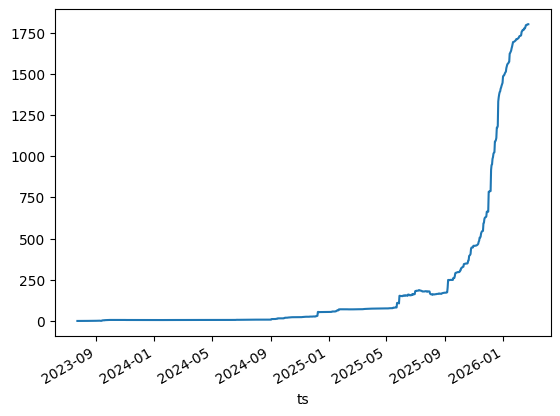

In [9]:
raw_pnl_mat.cumsum().plot()
16*raw_pnl_mat.mean()/raw_pnl_mat.std()

np.float64(4.63126406470173)

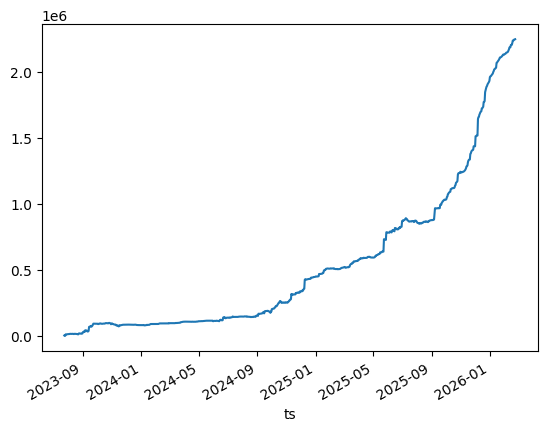

In [10]:
VaR = 1e4
(VaR*norm_pnl_mat).cumsum().plot()
16*norm_pnl_mat.mean()/norm_pnl_mat.std()